<a href="https://colab.research.google.com/github/pachterlab/CJP_2025/blob/main/notebooks/frhoPCA_covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE190nnn/GSE190001/suppl/GSE190001_COVAX_raw_count_BOOST.txt.gz
!wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE190nnn/GSE190001/suppl/GSE190001_COVAX_raw_count_PRIME.txt.gz
!wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE190nnn/GSE190001/matrix/GSE190001_series_matrix.txt.gz

--2026-03-24 18:48:18--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE190nnn/GSE190001/suppl/GSE190001_COVAX_raw_count_BOOST.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.11, 130.14.250.12, 2607:f220:41e:250::7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4313951 (4.1M) [application/x-gzip]
Saving to: ‘GSE190001_COVAX_raw_count_BOOST.txt.gz’

GSE190001_COVAX_raw 100%[===================>]   4.11M  2.92MB/s    in 1.4s    

2026-03-24 18:48:20 (2.92 MB/s) - ‘GSE190001_COVAX_raw_count_BOOST.txt.gz’ saved [4313951/4313951]

--2026-03-24 18:48:20--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE190nnn/GSE190001/suppl/GSE190001_COVAX_raw_count_PRIME.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.11, 130.14.250.12, 2607:f220:41e:250::7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.11|:443... connected.
HTTP re

In [ ]:
# install necessary packages
!pip install -q pydeseq2 anndata scikit-fda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 5.1 MB/s eta 0:00:00


In [ ]:
from io import StringIO

import pandas as pd
import numpy as np
import scipy

import gzip

import anndata as ad

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
boost = pd.read_csv('GSE190001_COVAX_raw_count_BOOST.txt.gz',sep='\t')
boost = boost.set_index('ID')
prime = pd.read_csv('GSE190001_COVAX_raw_count_PRIME.txt.gz',sep='\t')
prime = prime.set_index('ID')

In [ ]:
# load in metadata
fname = "GSE190001_series_matrix.txt.gz"

sample_fields = {}

n = 1

with gzip.open(fname, "rt") as f:
    for line in f:
        if not line.startswith("!Sample_"):
            continue

        # Split on tabs
        parts = line.rstrip("\n").split("\t")

        # Field name (remove !Sample_)
        field = parts[0].replace("!Sample_", "")

        if field in sample_fields.keys():
          field = field+f'_{n}'
          n += 1

        # Values per sample (strip quotes)
        values = [p.strip('"') for p in parts[1:]]

        sample_fields[field] = values

obs = pd.DataFrame(sample_fields)

In [ ]:
obs['Index'] = obs['description']
obs = obs.set_index('Index')
obs['patient'] = obs['title'].str.split('_').str[0]
obs['time'] = obs['title'].str.split('_').str[1]
obs = obs[['patient','time']]

Now, normalize data.

In [ ]:
dds_boost = DeseqDataSet(
    counts = boost.values.T,
    metadata = obs[obs.index.isin(boost.columns)],
    design_factors="time",
    inference=DefaultInference()
)

dds_boost.fit_size_factors()
norm_boost = dds_boost.layers["normed_counts"]

dds_prime = DeseqDataSet(
    counts = prime.values.T,
    metadata = obs[obs.index.isin(prime.columns)] ,
    design_factors="time",
    inference=DefaultInference()
)

dds_prime.fit_size_factors()
norm_prime = dds_prime.layers["normed_counts"]

/tmp/ipykernel_565/1760386229.py:1: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds_boost = DeseqDataSet(
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.78 seconds.

/tmp/ipykernel_565/1760386229.py:11: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds_prime = DeseqDataSet(
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.65 seconds.



In [ ]:
# genes in the A28 module

data = """Aggregate	Position	Module	Gene	Function
A28	A28.6	M8.3	EPSTI1	Type 1 Interferon
A28	A28.6	M8.3	HERC5	Type 1 Interferon
A28	A28.6	M8.3	HES4	Type 1 Interferon
A28	A28.6	M8.3	IFI44	Type 1 Interferon
A28	A28.6	M8.3	IFI44L	Type 1 Interferon
A28	A28.6	M8.3	IFI6	Type 1 Interferon
A28	A28.6	M8.3	IFIT1	Type 1 Interferon
A28	A28.6	M8.3	IFIT3	Type 1 Interferon
A28	A28.6	M8.3	ISG15	Type 1 Interferon
A28	A28.6	M8.3	LY6E	Type 1 Interferon
A28	A28.6	M8.3	MX1	Type 1 Interferon
A28	A28.6	M8.3	OAS1	Type 1 Interferon
A28	A28.6	M8.3	OAS2	Type 1 Interferon
A28	A28.6	M8.3	OAS3	Type 1 Interferon
A28	A28.6	M8.3	OASL	Type 1 Interferon
A28	A28.6	M8.3	RSAD2	Type 1 Interferon
A28	A28.6	M8.3	XAF1	Type 1 Interferon
A28	A28.1	M10.1	DDX58	Interferon
A28	A28.1	M10.1	DDX60	Interferon
A28	A28.1	M10.1	DHX58	Interferon
A28	A28.1	M10.1	FBXO6	Interferon
A28	A28.1	M10.1	GBP1	Interferon
A28	A28.1	M10.1	GBP4	Interferon
A28	A28.1	M10.1	GBP5	Interferon
A28	A28.1	M10.1	IFI35	Interferon
A28	A28.1	M10.1	IFIH1	Interferon
A28	A28.1	M10.1	IFIT2	Interferon
A28	A28.1	M10.1	IFIT5	Interferon
A28	A28.1	M10.1	IRF7	Interferon
A28	A28.1	M10.1	LAP3	Interferon
A28	A28.1	M10.1	OAS2	Interferon
A28	A28.1	M10.1	PARP12	Interferon
A28	A28.1	M10.1	PARP14	Interferon
A28	A28.1	M10.1	SAMD9L	Interferon
A28	A28.1	M10.1	SCO2	Interferon
A28	A28.1	M10.1	STAT1	Interferon
A28	A28.1	M10.1	TRIM22	Interferon
A28	A28.1	M10.1	ZBP1	Interferon
A28	A28.3	M13.17	ACTA2	Interferon
A28	A28.3	M13.17	ADAR	Interferon
A28	A28.3	M13.17	CASP1	Interferon
A28	A28.3	M13.17	CHMP5	Interferon
A28	A28.3	M13.17	DTX3L	Interferon
A28	A28.3	M13.17	GBP2	Interferon
A28	A28.3	M13.17	HS.489254	Interferon
A28	A28.3	M13.17	IFI16	Interferon
A28	A28.3	M13.17	IFITM1	Interferon
A28	A28.3	M13.17	IL1F7	Interferon
A28	A28.3	M13.17	IRF9	Interferon
A28	A28.3	M13.17	LGALS9	Interferon
A28	A28.3	M13.17	NOD2	Interferon
A28	A28.3	M13.17	NT5C3	Interferon
A28	A28.3	M13.17	PARP9	Interferon
A28	A28.3	M13.17	PHF11	Interferon
A28	A28.3	M13.17	PSMB9	Interferon
A28	A28.3	M13.17	RNF213	Interferon
A28	A28.3	M13.17	SAMD9	Interferon
A28	A28.3	M13.17	SHISA5	Interferon
A28	A28.3	M13.17	SP100	Interferon
A28	A28.3	M13.17	SP110	Interferon
A28	A28.3	M13.17	STAT2	Interferon
A28	A28.3	M13.17	TAP1	Interferon
A28	A28.3	M13.17	TDRD7	Interferon
A28	A28.3	M13.17	TMEM140	Interferon
A28	A28.3	M13.17	TRAFD1	Interferon
A28	A28.3	M13.17	TRIM21	Interferon
A28	A28.3	M13.17	UBE2L6	Interferon
A28	A28.3	M13.17	ZC3HAV1	Interferon
A28	A28.3	M13.17	ZNFX1	Interferon
A28	A28.4	M15.64	ACOT9	Interferon
A28	A28.4	M15.64	ADRA1D	Interferon
A28	A28.4	M15.64	APOB48R	Interferon
A28	A28.4	M15.64	APOL2	Interferon
A28	A28.4	M15.64	C1GALT1	Interferon
A28	A28.4	M15.64	CCR1	Interferon
A28	A28.4	M15.64	COP1	Interferon
A28	A28.4	M15.64	DYNLT1	Interferon
A28	A28.4	M15.64	ECGF1	Interferon
A28	A28.4	M15.64	H2AFJ	Interferon
A28	A28.4	M15.64	ISG20	Interferon
A28	A28.4	M15.64	KIAA0319L	Interferon
A28	A28.4	M15.64	LBA1	Interferon
A28	A28.4	M15.64	NEXN	Interferon
A28	A28.4	M15.64	PSMB9	Interferon
A28	A28.4	M15.64	RHBDF2	Interferon
A28	A28.4	M15.64	SP100	Interferon
A28	A28.4	M15.64	TNFSF13B	Interferon
A28	A28.4	M15.64	TRIM38	Interferon
A28	A28.4	M15.64	TRIM56	Interferon
A28	A28.4	M15.64	UNC93B1	Interferon
A28	A28.2	M15.86	ANKRD22	Interferon
A28	A28.2	M15.86	EIF2AK2	Interferon
A28	A28.2	M15.86	ENDOGL1	Interferon
A28	A28.2	M15.86	FCGR1B	Interferon
A28	A28.2	M15.86	GALM	Interferon
A28	A28.2	M15.86	HS.306876	Interferon
A28	A28.2	M15.86	KIAA1618	Interferon
A28	A28.2	M15.86	MOV10	Interferon
A28	A28.2	M15.86	MT1A	Interferon
A28	A28.2	M15.86	MT2A	Interferon
A28	A28.2	M15.86	PARP10	Interferon
A28	A28.2	M15.86	PRIC285	Interferon
A28	A28.2	M15.86	SP140	Interferon
A28	A28.2	M15.86	TIMM10	Interferon
A28	A28.2	M15.86	UBE2L6	Interferon
A28	A28.5	M15.127	CMPK2	Interferon
A28	A28.5	M15.127	HS.125087	Interferon
A28	A28.5	M15.127	HS.386275	Interferon
A28	A28.5	M15.127	IFI27	Interferon
A28	A28.5	M15.127	IFIT1	Interferon
A28	A28.5	M15.127	IFITM3	Interferon
A28	A28.5	M15.127	LAMP3	Interferon
A28	A28.5	M15.127	LOC26010	Interferon
A28	A28.5	M15.127	OAS1	Interferon
A28	A28.5	M15.127	OAS2	Interferon
A28	A28.5	M15.127	OASL	Interferon
A28	A28.5	M15.127	OTOF	Interferon
A28	A28.5	M15.127	SERPING1	Interferon
A28	A28.5	M15.127	TRIM6	Interferon
"""

df_a28 = pd.read_csv(StringIO(data), sep="\t")



In [ ]:
ensg_data = """initial_alias	converted_alias
LAP3	ENSG00000002549
EIF2AK2	ENSG00000055332
PARP12	ENSG00000059378
SP100	ENSG00000067066
SP100	ENSG00000067066
IFI35	ENSG00000068079
LAMP3	ENSG00000078081
SP140	ENSG00000079263
CHMP5	ENSG00000086065
OAS1	ENSG00000089127
OAS1	ENSG00000089127
TNFSF13B	ENSG00000102524
ZC3HAV1	ENSG00000105939
C1GALT1	ENSG00000106392
ACTA2	ENSG00000107796
DHX58	ENSG00000108771
UNC93B1	ENSG00000110057
OAS3	ENSG00000111331
OAS2	ENSG00000111335
OAS2	ENSG00000111335
OAS2	ENSG00000111335
TRIM38	ENSG00000112343
OTOF	ENSG00000115155
IFIH1	ENSG00000115267
STAT1	ENSG00000115415
FBXO6	ENSG00000116663
GBP1	ENSG00000117228
IFIT3	ENSG00000119917
IFIT2	ENSG00000119922
TRIM6	ENSG00000121236
NT5C3	ENSG00000122643
ACOT9	ENSG00000123130
ZNFX1	ENSG00000124201
ZBP1	ENSG00000124256
MT2A	ENSG00000125148
IFI6	ENSG00000126709
APOL2	ENSG00000128335
RHBDF2	ENSG00000129667
TRIM21	ENSG00000132109
TRIM22	ENSG00000132274
XAF1	ENSG00000132530
EPSTI1	ENSG00000133106
RSAD2	ENSG00000134321
CMPK2	ENSG00000134326
TIMM10	ENSG00000134809
OASL	ENSG00000135114
TRAFD1	ENSG00000135148
SP110	ENSG00000135899
PHF11	ENSG00000136147
DDX60	ENSG00000137628
CASP1	ENSG00000137752
IFI44L	ENSG00000137959
IFI44	ENSG00000137965
PARP9	ENSG00000138496
HERC5	ENSG00000138646
IFITM3	ENSG00000142089
KIAA0319L	ENSG00000142687
COP1	ENSG00000143207
GALM	ENSG00000143891
DYNLT1	ENSG00000146425
TMEM140	ENSG00000146859
SERPING1	ENSG00000149131
ANKRD22	ENSG00000152766
IFIT5	ENSG00000152778
GBP5	ENSG00000154451
MOV10	ENSG00000155363
UBE2L6	ENSG00000156587
MX1	ENSG00000157601
ADAR	ENSG00000160710
LY6E	ENSG00000160932
NEXN	ENSG00000162614
GBP2	ENSG00000162645
GBP4	ENSG00000162654
IFI16	ENSG00000163565
CCR1	ENSG00000163823
DTX3L	ENSG00000163840
SHISA5	ENSG00000164054
IFI27	ENSG00000165949
NOD2	ENSG00000167207
TAP1	ENSG00000168394
LGALS9	ENSG00000168961
TRIM56	ENSG00000169871
STAT2	ENSG00000170581
ADRA1D	ENSG00000171873
ISG20	ENSG00000172183
PARP14	ENSG00000173193
RNF213	ENSG00000173821
SAMD9L	ENSG00000177409
PARP10	ENSG00000178685
IRF7	ENSG00000185507
IFIT1	ENSG00000185745
IFITM1	ENSG00000185885
ISG15	ENSG00000187608
HES4	ENSG00000188290
TDRD7	ENSG00000196116
MT1A	ENSG00000205362
SAMD9	ENSG00000205413
IRF9	ENSG00000213928
PSMB9	ENSG00000240065
SCO2	ENSG00000284194
"""

ensg_df = pd.read_csv(StringIO(ensg_data), sep="\t")

In [ ]:

df = df_a28.merge(
    ensg_df,
    how="left",
    left_on="Gene",
    right_on="initial_alias"
)

df = df.rename(columns={"converted_alias": "ENSG"})

In [ ]:
dds_prime.var.index = prime.index
dds_prime.obs.index = prime.columns
dds_boost.var.index = boost.index
dds_boost.obs.index =  boost.columns

In [ ]:
dds_prime.obs['t'] = dds_prime.obs['time'].str.split('D').str[-1].astype(int)
dds_boost.obs['t'] = dds_boost.obs['time'].str.split('D').str[-1].astype(int)
dds_prime.obs['t'][dds_prime.obs.t!=14] = dds_prime.obs['t'].values[dds_prime.obs.t!=14] - 1
dds_boost.obs['t'][dds_boost.obs.t!=14] = dds_boost.obs['t'].values[dds_boost.obs.t!=14] - 1

/tmp/ipykernel_565/3022577655.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dds_prime.obs['t'][dds_prime.obs.t!=14] = dds_prime.obs['t'].values[dds_prime.obs.t!=14] - 1
/tmp/ipykernel_565/3022577655.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dds_boost.obs['t'][dds_boost.obs.t!=14] = dds_boost.obs['t'].values[dds_boost.obs.t!=14] - 1


# Perform functional rhoPCA

In [ ]:
import skfda
from skfda.datasets import fetch_growth
from skfda.preprocessing.dim_reduction import FPCA
from skfda.representation.basis import BSplineBasis, MonomialBasis

from sklearn.metrics import silhouette_score

from scipy.linalg import eigh

In [ ]:
def get_dfs(g):


  df_prime = dds_prime.obs
  df_boost = dds_boost.obs
  df_prime['count'] = np.array(dds_prime[:,g].layers['normed_counts'].flatten())
  df_boost['count'] = np.array(dds_boost[:,g].layers['normed_counts'].flatten())

  baseline = df_prime[df_prime['t'] == 0].set_index('patient')['count']
  df_prime['baseline_val'] = df_prime['patient'].map(baseline)
  df_prime = df_prime.dropna(subset=['baseline_val']).copy()
  df_prime['count_rel'] = df_prime['count'] / df_prime['baseline_val']
  df_prime['patient_vaccine'] = df_prime.patient.astype(str) + '_' + 'P'

  baseline = df_boost[df_boost['t'] == 0].set_index('patient')['count']
  df_boost['baseline_val'] = df_boost['patient'].map(baseline)
  df_boost = df_boost.dropna(subset=['baseline_val']).copy()
  df_boost['count_rel'] = df_boost['count'] / df_boost['baseline_val']
  df_boost['patient_vaccine'] = df_boost.patient.astype(str) + '_' + 'B'

  df_ = pd.concat([df_prime,df_boost])
  df_cleaned = df_.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

  df_boost_clean = df_boost.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
  df_prime_clean = df_prime.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
  return df_cleaned, df_boost_clean, df_prime_clean, df_prime, df_boost


def get_fd(df_cleaned, df_boost_clean, df_prime_clean):
  indices = df_cleaned.groupby('patient_vaccine')['t'].apply(lambda x: x.values).tolist()
  values = df_cleaned.groupby('patient_vaccine')['count_rel'].apply(lambda x: x.values).tolist()

  fd_irregular = skfda.representation.irregular.FDataIrregular(
      start_indices=np.cumsum([0] + [len(i) for i in indices[:-1]]),
      points=np.concatenate(indices),
      values=np.concatenate(values)
  )

  indices = df_boost_clean.groupby('patient')['t'].apply(lambda x: x.values).tolist()
  values = df_boost_clean.groupby('patient')['count_rel'].apply(lambda x: x.values).tolist()

  fd_boost = skfda.representation.irregular.FDataIrregular(
      start_indices=np.cumsum([0] + [len(i) for i in indices[:-1]]),
      points=np.concatenate(indices),
      values=np.concatenate(values)
  )

  indices = df_prime_clean.groupby('patient')['t'].apply(lambda x: x.values).tolist()
  values = df_prime_clean.groupby('patient')['count_rel'].apply(lambda x: x.values).tolist()

  fd_prime = skfda.representation.irregular.FDataIrregular(
      start_indices=np.cumsum([0] + [len(i) for i in indices[:-1]]),
      points=np.concatenate(indices),
      values=np.concatenate(values)
  )

  return(fd_irregular,fd_boost,fd_prime)


def get_coefficients(df,fd,basis):
  t_min, t_max = df['t'].min(), df['t'].max()
  fd_basis = fd.to_basis(basis)
  coefficients = fd_basis.coefficients
  return(coefficients)


# now do rhoPCA
def rho_fpca_basis(A_fg, A_bg, basis, eps=1e-6):
    """
    Functional ρPCA in basis using Gram-matrix geometry. Returns coefficients of evecs for basis.
    """
    G = basis.gram_matrix()
    A_fg_c = A_fg - A_fg.mean(axis=0)
    A_bg_c = A_bg - A_bg.mean(axis=0)

    l_matrix = np.linalg.cholesky(G)
    l_inv_g_t = scipy.linalg.solve_triangular(
            l_matrix,
            np.transpose(G),
            lower=True)

    whitened_fg = A_fg_c @ np.transpose(l_inv_g_t)
    whitened_bg = A_bg_c @ np.transpose(l_inv_g_t)
    cov_fg = np.cov(whitened_fg, rowvar=False)
    cov_bg = np.cov(whitened_bg, rowvar=False)

    # vals, vecs = eigh(cov_fg , cov_bg + np.eye(len(cov_fg))*eps)
    vals, vecs = eigh(cov_fg , cov_bg)
    vecs = scipy.linalg.solve_triangular(l_matrix.T, vecs, lower=False)   # the vectors are not transposed like in sklearn-fpca because eigh has different convention than PCA


    # return vals[idx], vecs[:, idx]
    # fix convention of returned vecs
    for i,vec_ in enumerate(vecs.T):
        max_ = np.where(np.abs(vec_) == np.max(np.abs(vec_)))[0]
        if vec_[max_] < 0:
            vec_ *= -1
        vecs[:,i] = vec_

    GE1_coeffs = vecs[:,-1]
    GE2_coeffs = vecs[:,-2]

    GE1_fd = skfda.representation.basis.FDataBasis(basis, GE1_coeffs)
    GE2_fd = skfda.representation.basis.FDataBasis(basis, GE2_coeffs)

    return vals, vecs, GE1_fd, GE2_fd


def r2_mask(fd_irregular, basis, threshold=0.8):

    fd_basis = fd_irregular.to_basis(basis)

    keep_mask = []

    for i in range(fd_irregular.n_samples):

        t_obs = fd_irregular[i].points
        y_obs = fd_irregular[i].values.flatten()
        y_hat = fd_basis[i](t_obs).flatten()

        ss_res = np.sum((y_obs - y_hat)**2)
        ss_tot = np.sum((y_obs - np.mean(y_obs))**2)


        if ss_tot == 0:
            keep_mask.append(False)
        else:
            r2 = 1 - ss_res / ss_tot
            keep_mask.append(r2 > threshold)
            # print(r2)

    return np.array(keep_mask)


ENSG00000133106 14 11
ENSG00000138646 15 13
ENSG00000188290 5 2
5 2
ENSG00000137965 15 12
ENSG00000137959 17 13
ENSG00000126709 19 10
ENSG00000185745 17 13
ENSG00000119917 16 11
ENSG00000187608 12 7
ENSG00000160932 15 7
ENSG00000157601 18 13
ENSG00000089127 16 8
ENSG00000111335 14 13
ENSG00000111331 18 12
ENSG00000135114 11 7
ENSG00000134321 18 8
ENSG00000132530 13 15
Skipping nan because of error: Unknown indexer nan of type <class 'float'>
ENSG00000137628 13 11
ENSG00000108771 14 8
ENSG00000116663 8 6
8 6
ENSG00000117228 5 9
5 9
ENSG00000162654 6 13
6 13
ENSG00000154451 7 11
ENSG00000068079 9 10
ENSG00000115267 12 13
ENSG00000119922 16 11
ENSG00000152778 17 13
ENSG00000185507 10 7
ENSG00000002549 7 7
ENSG00000002549 7 7


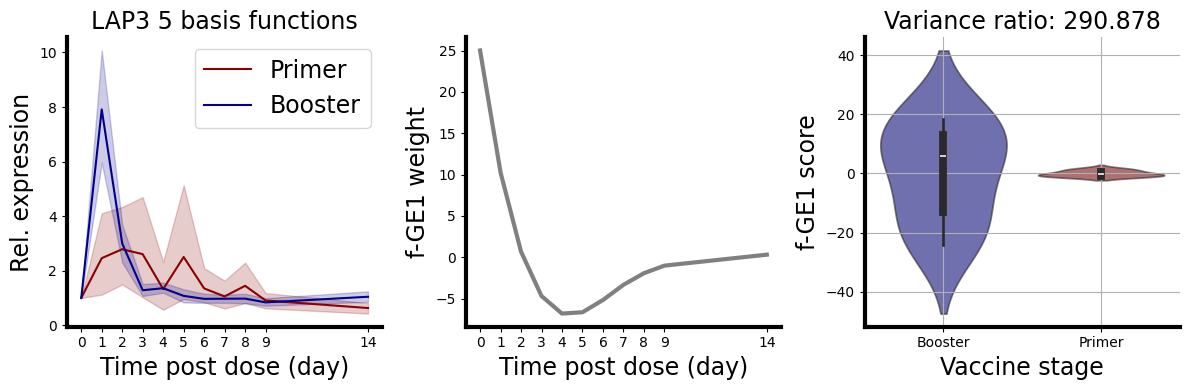

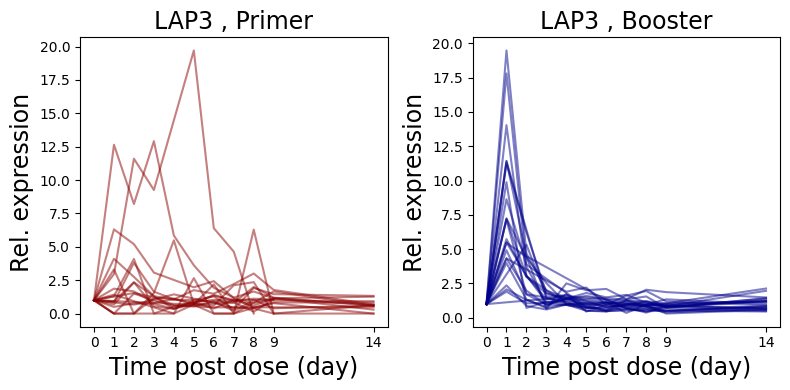

ENSG00000059378 11 12
ENSG00000173193 9 10
ENSG00000177409 11 11
Skipping ENSG00000284194 because of error: need at least one array to concatenate
ENSG00000115415 11 15
ENSG00000132274 11 13
ENSG00000124256 10 6
10 6
ENSG00000107796 9 6
9 6
ENSG00000160710 10 12
ENSG00000137752 14 11
ENSG00000086065 9 14
ENSG00000163840 9 12
ENSG00000162645 7 10
ENSG00000162645 7 10


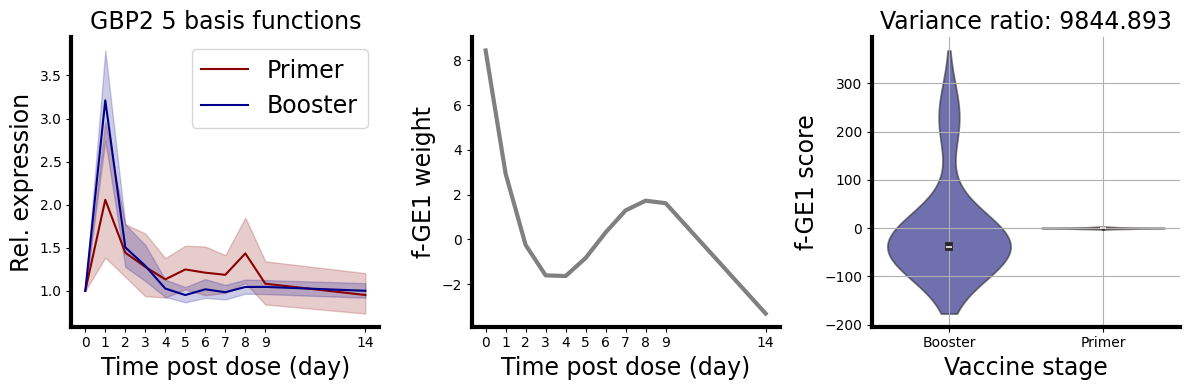

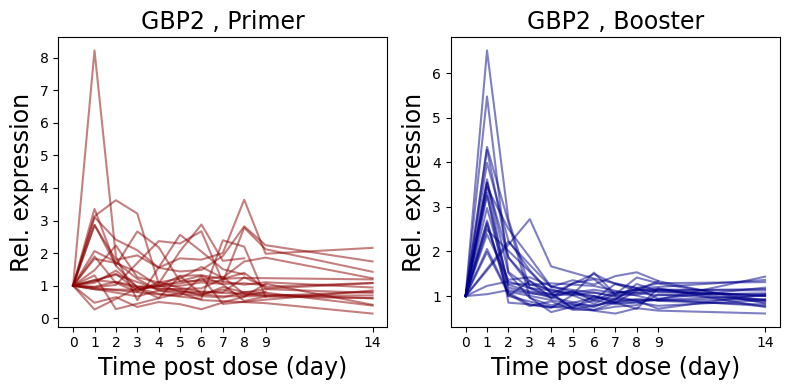

ENSG00000163565 9 9
ENSG00000185885 8 13
ENSG00000213928 14 10
ENSG00000168961 15 10
ENSG00000167207 7 9
ENSG00000122643 9 9
ENSG00000138496 12 14
ENSG00000136147 9 10
ENSG00000240065 8 11
ENSG00000173821 13 13
ENSG00000205413 13 12
ENSG00000164054 13 9
ENSG00000067066 10 12
ENSG00000135899 12 11
ENSG00000135899 12 11


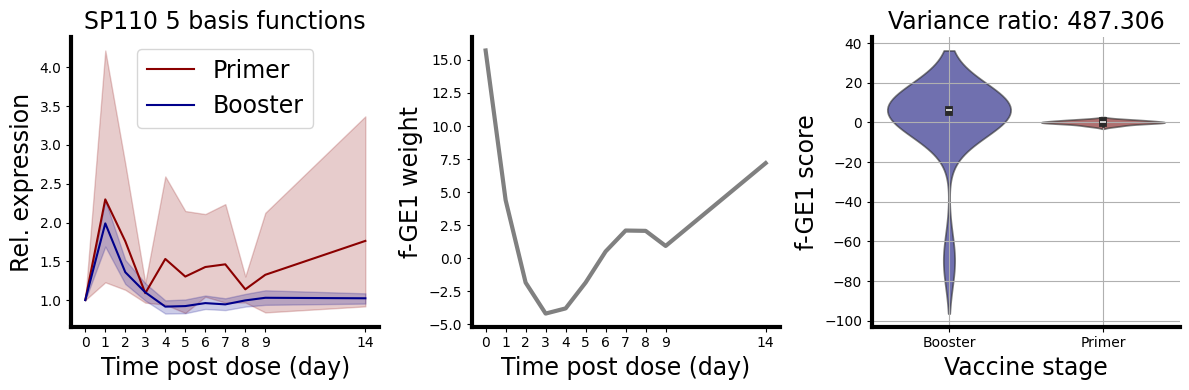

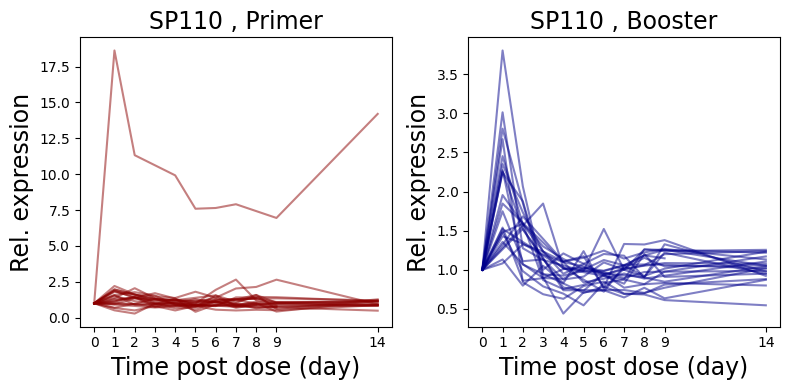

ENSG00000170581 10 10
ENSG00000168394 6 9
6 9
ENSG00000196116 12 9
ENSG00000146859 11 10
ENSG00000135148 9 10
ENSG00000132109 10 12
ENSG00000156587 9 13
ENSG00000105939 8 10
ENSG00000124201 10 14
ENSG00000123130 14 11
Skipping ENSG00000171873 because of error: need at least one array to concatenate
ENSG00000128335 7 9
ENSG00000106392 10 8
ENSG00000163823 16 11
ENSG00000143207 9 11
ENSG00000146425 9 10
ENSG00000172183 8 8
ENSG00000172183 8 8


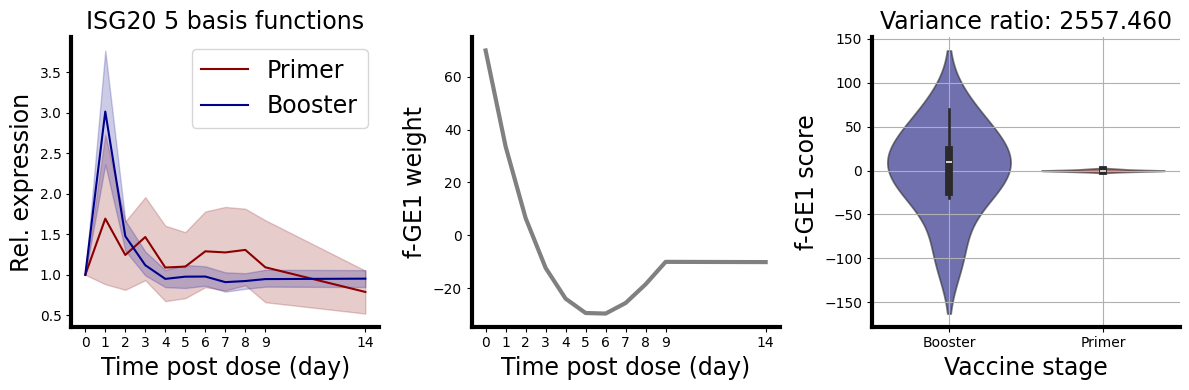

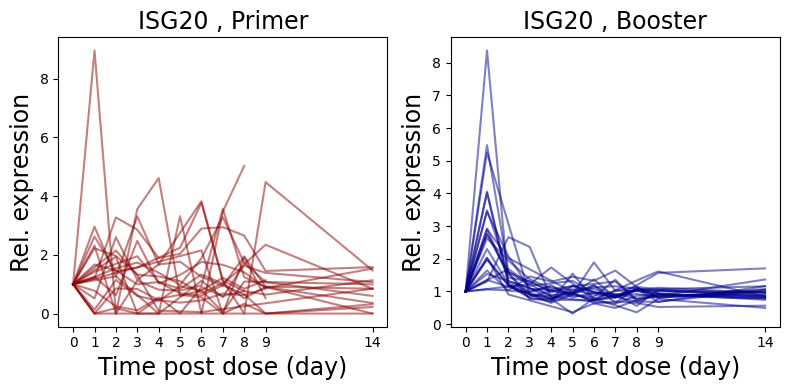

ENSG00000142687 13 11
ENSG00000162614 12 12
ENSG00000129667 8 11
ENSG00000102524 11 14
ENSG00000112343 12 11
ENSG00000169871 6 12
6 12
ENSG00000110057 9 8
ENSG00000152766 2 4
2 4
ENSG00000055332 15 14
ENSG00000143891 10 5
10 5
ENSG00000155363 9 8
Skipping ENSG00000205362 because of error: need at least one array to concatenate
ENSG00000125148 13 8
ENSG00000178685 5 7
5 7
ENSG00000079263 9 10
ENSG00000134809 10 10
ENSG00000134326 16 11
ENSG00000165949 19 11
ENSG00000142089 15 8
ENSG00000078081 5 4
5 4
ENSG00000115155 0 1
0 1
ENSG00000149131 10 6
10 6
ENSG00000121236 8 4
8 4


In [ ]:
# for many genes
c_prime = 'darkred'
c_boost = 'darkblue'
fs = 17
t_eval = np.array([0,1,2,3,4,5,6,7,8,9,14])

n = 5   # 5 basis functions
basis = BSplineBasis(n_basis=n, domain_range=(0, 14))

r2_threshold = 0.5
samp_threshold = 7

fit_genes = []
num_boost = []
num_prime = []
ss_list = []
var_list = []
GE1_list = []
scores_GE1_fg_list = []
scores_GE2_fg_list = []
scores_GE1_bg_list = []
scores_GE2_bg_list = []

# NEW: collect per-gene patient info here
patient_summary_rows = []

genes = list(df.ENSG.unique())
genes_to_plot = ['GBP2','ISG20','SP110','LAP3','ISG15','IRF7']
genes_to_plot = ['GBP2','ISG20','SP110','LAP3']

for g, gene in enumerate(genes):
    try:
        df_cleaned, df_boost_clean, df_prime_clean, df_prime, df_boost = get_dfs(gene)
        fd_irregular, fd_boost, fd_prime = get_fd(
            df_cleaned, df_boost_clean, df_prime_clean
        )

        mask_boost = r2_mask(fd_boost, basis, r2_threshold)
        mask_prime = r2_mask(fd_prime, basis, r2_threshold)

        print(gene, mask_boost.sum(), mask_prime.sum())

        if mask_boost.sum() < samp_threshold or mask_prime.sum() < samp_threshold:
            print(mask_boost.sum(), mask_prime.sum())
            continue

        # ---- NEW: get patient IDs that passed the mask ----
        # If df_prime_clean / df_boost_clean have one row per patient, this is enough.
        prime_patients_used = (
            df_prime_clean.loc[:,'patient']
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        boost_patients_used = (
            df_boost_clean.loc[:,'patient']
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        gene_name = df.loc[df.ENSG == gene, 'Gene'].iloc[0]

        patient_summary_rows.append({
            'gene_name': gene_name,
            'gene_id': gene,
            'n_patients_primer': len(prime_patients_used),
            'patients_primer': prime_patients_used,
            'n_patients_booster': len(boost_patients_used),
            'patients_booster': boost_patients_used,
        })
        # -----------------------------------------------

        num_boost.append(mask_boost.sum())
        num_prime.append(mask_prime.sum())

        A_fg = get_coefficients(df_boost_clean, fd_boost, basis)
        A_bg = get_coefficients(df_prime_clean, fd_prime, basis)

        A_fg = A_fg[mask_boost]
        A_bg = A_bg[mask_prime]

        vals, vecs, GE1_fd, GE2_fd = rho_fpca_basis(A_fg, A_bg, basis)
        GE1_smooth = GE1_fd(t_eval).flatten()
        GE2_smooth = GE2_fd(t_eval).flatten()

        GE1_list.append(GE1_smooth / GE1_smooth.max())

        fg_mean = A_fg.mean(axis=0)
        A_fg_centered = A_fg - fg_mean
        bg_mean = A_bg.mean(axis=0)
        A_bg_centered = A_bg - bg_mean

        G = basis.gram_matrix()

        GE1_coeffs = vecs[:, -1]
        GE2_coeffs = vecs[:, -2]

        scores_GE1_fg = A_fg_centered @ G @ GE1_coeffs
        scores_GE2_fg = A_fg_centered @ G @ GE2_coeffs
        scores_GE1_bg = A_bg_centered @ G @ GE1_coeffs
        scores_GE2_bg = A_bg_centered @ G @ GE2_coeffs

        scores_GE1_fg_list.append(scores_GE1_fg)
        scores_GE2_fg_list.append(scores_GE2_fg)
        scores_GE1_bg_list.append(scores_GE1_bg)
        scores_GE2_bg_list.append(scores_GE2_bg)

        n_boost = A_fg.shape[0]
        n_prime = A_bg.shape[0]

        var_boost = np.var(scores_GE1_fg)
        var_prime = np.var(scores_GE1_bg)
        var_rat = var_boost / var_prime
        var_list.append(var_rat)
        fit_genes.append(gene)

        gene_name = df[df.ENSG == gene].Gene.values[0]
        if gene_name in genes_to_plot:
            print(gene, mask_boost.sum(), mask_prime.sum())
            fig, ax = plt.subplots(1, 3, figsize=(12, 4))

            sns.lineplot(df_prime, ax=ax[0], color=c_prime, x='t', y='count_rel', label='Primer')
            sns.lineplot(df_boost, ax=ax[0], color=c_boost, x='t', y='count_rel', label='Booster')
            ax[0].legend(fontsize=fs)
            ax[0].set_title(df[df.ENSG == gene].Gene.values[0] + ' ' + str(n) + ' basis functions', fontsize=fs)
            ax[0].set_ylabel('Rel. expression', fontsize=fs)
            ax[0].set_xlabel('Time post dose (day)', fontsize=fs)
            ax[0].set_xticks(t_eval)

            ax[1].plot(t_eval, GE1_smooth, label="f-GE1", linewidth=3.0, color='gray')
            ax[1].set_ylabel('f-GE1 weight', fontsize=fs)
            ax[1].set_xlabel('Time post dose (day)', fontsize=fs)
            ax[1].set_xticks(t_eval)

            score_df = pd.DataFrame({
                'Score': np.concatenate([scores_GE1_fg, scores_GE1_bg]),
                'Vaccine': ['Booster'] * n_boost + ['Primer'] * n_prime
            })
            sns.violinplot(
                data=score_df, x='Vaccine', y='Score', ax=ax[2],
                palette=[c_boost, c_prime], alpha=0.6
            )

            ax[2].set_xlabel("Vaccine stage", fontsize=fs)
            ax[2].set_ylabel("f-GE1 score", fontsize=fs)
            ax[2].set_title(f"Variance ratio: {var_rat:.3f}", fontsize=fs)
            ax[2].grid(True)

            for i in range(3):
                ax[i].spines['top'].set_visible(False)
                ax[i].spines['right'].set_visible(False)
                ax[i].spines['left'].set_linewidth(3)
                ax[i].spines['bottom'].set_linewidth(3)
                ax[i].xaxis.set_ticks_position('bottom')
                ax[i].yaxis.set_ticks_position('left')

            plt.tight_layout()
            plt.show()

            fig, ax = plt.subplots(1, 2, figsize=(8, 4))

            sns.lineplot(
                data=df_prime,
                ax=ax[0],
                x='t',
                y='count_rel',
                units='patient',
                estimator=None,
                alpha=0.5,
                color=c_prime,
                # legend=False
            )

            sns.lineplot(
                data=df_boost,
                ax=ax[1],
                x='t',
                y='count_rel',
                units='patient',
                estimator=None,
                alpha=0.5,
                color=c_boost,
                # legend=False
            )

            ax[0].set_title(df[df.ENSG == gene].Gene.values[0] + ' , Primer', fontsize=fs)
            ax[0].set_ylabel('Rel. expression', fontsize=fs)
            ax[0].set_xlabel('Time post dose (day)', fontsize=fs)
            ax[0].set_xticks(t_eval)

            ax[1].set_title(df[df.ENSG == gene].Gene.values[0] + ' , Booster', fontsize=fs)
            ax[1].set_ylabel('Rel. expression', fontsize=fs)
            ax[1].set_xlabel('Time post dose (day)', fontsize=fs)
            ax[1].set_xticks(t_eval)
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Skipping {gene} because of error: {e}")


patient_summary_df = pd.DataFrame(patient_summary_rows)




In [ ]:
patient_summary_df.to_csv('frhoPCA_patients_fit_covid.csv')

In [ ]:
var_map = {g : var for g,var in zip(fit_genes,var_list)}
df['Variance Ratio'] = df['ENSG'].map(var_map)

In [ ]:
df_rat = df.dropna()

In [ ]:
df_rat = df_rat.drop_duplicates()
df_rat = df_rat.sort_values('Variance Ratio',ascending=False)

/tmp/ipykernel_565/1962496790.py:36: UserWarning: The palette list has more values (86) than needed (78), which may not be intended.
  sns.barplot(x=df_rat.Gene,


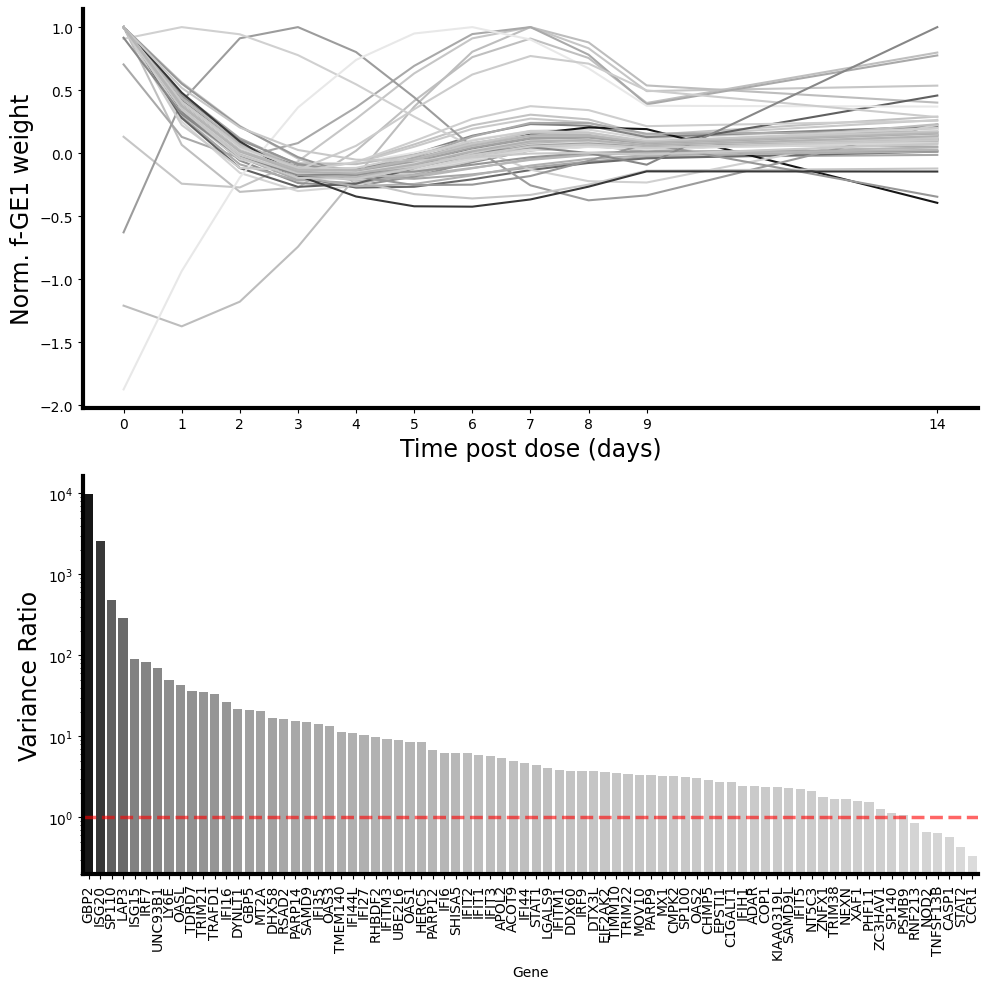

In [ ]:
import matplotlib as mpl

fig, ax = plt.subplots(2,1,figsize=(10,10))

var_ratios_log = np.log(np.array([
    df_rat[df_rat.ENSG == gene]['Variance Ratio'].values[0]
    for gene in fit_genes
]))


norm = mpl.colors.Normalize(vmin=var_ratios_log.min()-2,
                            vmax=var_ratios_log.max()+1)

cmap = plt.cm.Greys

for ge1, vr in zip(GE1_list, var_ratios_log):
    color = cmap(norm(vr))
    ax[0].plot(t_eval, ge1, color=color)

ax[0].xaxis.set_ticks_position('bottom')
ax[0].yaxis.set_ticks_position('left')
ax[0].set_ylabel('Norm. f-GE1 weight', fontsize=fs)
ax[0].set_xlabel('Time post dose (days)', fontsize=fs)
ax[0].set_xticks(t_eval)


df_rat = df_rat.copy()
df_rat["log_var_ratio"] = np.log(df_rat["Variance Ratio"])

bar_colors = [
    cmap(norm(v))
    for v in df_rat["log_var_ratio"]
]


sns.barplot(x=df_rat.Gene,
            y=df_rat["Variance Ratio"],
            palette=bar_colors,
            ax=ax[1])

ax[1].set_yscale('log')
ax[1].set_ylabel("Variance Ratio", fontsize=fs)
ax[1].axhline(1,color='red',linestyle='--',linewidth=2.5,alpha=0.6)

plt.xticks(rotation=90)

for i in range(2):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['left'].set_linewidth(3)
    ax[i].spines['bottom'].set_linewidth(3)

plt.tight_layout()


